<a href="https://colab.research.google.com/github/kofisarf/Plant-Disease-Detection-Group-9/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Disease Detection for Ghanaian Smallholder Farmers
### Group 9 — Introduction to Artificial Intelligence Final Project

## 1. Background & Problem

Agriculture is one of the biggest pillars of Ghana's economy — it made up roughly **22.8% of national GDP in 2025** and employs about **one-third of the country's workforce**, much of it made up of small-scale farmers growing staples like maize, cassava, tomatoes, rice, and soybeans. The Ministry of Food and Agriculture (MoFA) has identified **plant disease** as one of the leading causes of crop failure in the country.

The root of the problem is access: Ghana has far too few agricultural extension officers for the number of farmers who need them (often several hundred farmers per officer), so most farmers end up relying on informal advice or their own visual inspection to diagnose sick crops. This leads to frequent misdiagnosis and the misuse of pesticides, which wastes money, harms yields, and can make the actual disease worse.

## 2. Our Problem Statement

> Can we build an image-based machine learning model that accurately detects diseases in key Ghanaian crops from ordinary smartphone photos, so that smallholder farmers can get an early, reliable diagnosis without waiting for an extension officer?

## 3. Why This Matters to Us

This project isn't purely academic for our team — one of our members has a father who farms as a side business, and we've seen firsthand how quickly a crop disease can spiral from a manageable problem into total crop loss if it isn't caught early. Beyond that personal connection, we see this as a chance to build something that genuinely supports MoFA, extension services, and farmers who don't have easy access to expert help: instant, photo-based disease detection means faster treatment decisions and less preventable crop loss.

## 4. Our Approach

We use a **Convolutional Neural Network (CNN)** because it can automatically learn to recognize visual disease symptoms — leaf spots, blights, discoloration — directly from images, without us having to hand-engineer rules for every disease. This notebook walks through the full pipeline:

1. **Setup & data download** — pull the PlantVillage dataset from Kaggle.
2. **Data filtering & splitting** — keep only the crops we care about (Tomato, Corn/Maize, Potato, Pepper) and split into train/validation/test sets.
3. **Data generators** — load images in batches and augment the training set so the model generalizes better.
4. **Model definition & training** — build and train a baseline CNN.
5. **Evaluation** — measure accuracy, precision, recall, and visualize a confusion matrix.
6. **Demo samples** — pull sample images to sanity-check predictions.
7. **Live demo** — let anyone upload a leaf photo and get an instant prediction.

**Data source:** [PlantVillage dataset on Kaggle](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset), containing labeled images of healthy and diseased crops. We use a filtered subset (Tomato, Corn/Maize, Potato, Pepper) to keep training time manageable while still covering economically important Ghanaian crops.

**Tools:** Python, TensorFlow/Keras (model + `ImageDataGenerator` for preprocessing/augmentation), NumPy, Matplotlib/Seaborn (visualization), scikit-learn (evaluation metrics), Google Colab + Google Drive (GPU training and storage).


# Plant Disease Detection — Group 9
Cleaned and consolidated notebook. Cells are organized in the order they should be run:
1. Setup & data download
2. Data filtering & splitting
3. Data generators (with augmentation)
4. Model definition & training
5. Evaluation
6. Demo samples
7. Live demo functions


## 1. Setup & Data Download

**What this does:** Installs the Kaggle command-line tool inside the Colab environment. We need this so the notebook can talk to Kaggle's API and download the PlantVillage dataset directly, instead of manually downloading and re-uploading a multi-gigabyte zip file.

In [1]:
# Install the Kaggle CLI so we can pull datasets straight from Kaggle inside Colab
!pip install -q kaggle


**What this does:** Opens a file-upload prompt so we can provide our personal `kaggle.json` API credentials file (generated from a Kaggle account). Kaggle requires this file to authenticate API requests such as dataset downloads.

In [2]:
# Prompt for a file upload -- use this to upload your personal kaggle.json API key
from google.colab import files
files.upload()  # upload your kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kofiboadisarfo","key":"1fdca5f8b8c4444d8c10244e4b29ac88"}'}

**What this does:** Moves the uploaded `kaggle.json` credentials into the folder Kaggle's CLI expects (`~/.kaggle/`) and restricts its file permissions to read/write for the owner only (`chmod 600`). Kaggle refuses to use the credentials file if its permissions are too open, so this step is required, not optional.

In [3]:
# Create the Kaggle config folder, place our credentials there, and lock down permissions
# (Kaggle's CLI requires 600 permissions on kaggle.json to accept it)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


**What this does:** Downloads the PlantVillage dataset zip file from Kaggle using the authenticated CLI, then silently (`-q`) unzips it into a local `plantvillage_data/` folder so we can work with the raw images.

In [4]:
# Download the PlantVillage dataset from Kaggle, then unzip it locally
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plantvillage_data


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:40<00:00, 21.8MB/s]



## 2. Filter to Study Crops & Split Data

**What this does:** The full PlantVillage dataset covers many crops that aren't relevant to our project, so this cell filters it down to just the four crops we care about for the Ghanaian context — **Tomato, Corn (Maize), Potato, and Pepper**. It scans every folder name in the raw dataset, and if the folder name matches one of our target crops, it copies that whole folder into a new `Crop_data/` directory. This keeps our dataset focused and our training time manageable, while still covering economically important staple/commercial crops.

In [5]:
# Filter the full PlantVillage dataset down to only the crops we care about
import os
import shutil

# Location of the raw, unfiltered PlantVillage images and where we'll copy the filtered subset
source_dir = 'plantvillage_data/plantvillage dataset/color'
Crop_data = 'Crop_data'
os.makedirs(Crop_data, exist_ok=True)

# Crops relevant to our Ghanaian smallholder-farmer use case
Study_crops = ['Tomato', 'Corn_(maize)', 'Potato', 'Pepper']

# Walk through every class folder in the raw dataset and copy over only the ones
# that belong to one of our target crops (folder names encode crop + disease/health status)
for folder_name in os.listdir(source_dir):
    if any(crop in folder_name for crop in Study_crops):
        src_path = os.path.join(source_dir, folder_name)
        dst_path = os.path.join(Crop_data, folder_name)
        if not os.path.exists(dst_path):
            shutil.copytree(src_path, dst_path)
            print(f"Copied: {folder_name}")

print("Data filtering complete!")


Copied: Potato___healthy
Copied: Pepper,_bell___Bacterial_spot
Copied: Tomato___Late_blight
Copied: Tomato___Leaf_Mold
Copied: Potato___Late_blight
Copied: Corn_(maize)___Northern_Leaf_Blight
Copied: Corn_(maize)___Common_rust_
Copied: Tomato___Early_blight
Copied: Tomato___Tomato_mosaic_virus
Copied: Corn_(maize)___healthy
Copied: Tomato___healthy
Copied: Tomato___Bacterial_spot
Copied: Tomato___Spider_mites Two-spotted_spider_mite
Copied: Potato___Early_blight
Copied: Pepper,_bell___healthy
Copied: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Copied: Tomato___Target_Spot
Copied: Tomato___Septoria_leaf_spot
Copied: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Data filtering complete!


**What this does:** Installs the `split-folders` helper library, then uses it to automatically split our filtered `Crop_data/` into three separate folders — `train` (80%), `val` (10%), and `test` (10%) — with a fixed random `seed=42` so the split is reproducible across team members' runs. This three-way split lets us train on one portion, tune on another (validation), and get an honest, unbiased accuracy estimate on data the model has never seen (test).

In [6]:
# Install a helper library that splits an image dataset into train/val/test folders for us
!pip install -q split-folders

import splitfolders

# Split the filtered crop dataset into train (80%), validation (10%), and test (10%)
splitfolders.ratio(
    "Crop_data",
    output="data_split",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

print("Data successfully split into train, val, and test folders!")


Copying files: 26639 files [00:05, 5152.95 files/s]

Data successfully split into train, val, and test folders!


## 3. Data Generators (with Augmentation)
Augmentation is applied to the **training set only**. Validation and test sets stay unaugmented
so evaluation reflects clean, realistic images — augmenting them would make accuracy numbers
less trustworthy.

`brightness_range` is included to help the model generalize to real-world photos taken in
different lighting conditions (not just PlantVillage's studio-style images).

**What this does:** Sets up three `ImageDataGenerator` objects that will feed images into the model in batches during training/evaluation:

- `train_datagen` rescales pixel values to the 0–1 range and applies **data augmentation** (random rotation, shifts, shear, zoom, horizontal flips, and brightness jitter) *only* to the training images. This artificially creates more variety so the model doesn't just memorize the training photos, and it helps it generalize to real smartphone photos with imperfect angles and lighting.
- `val_test_datagen` only rescales pixel values — no augmentation — because we want validation and test accuracy to reflect performance on clean, realistic images, not artificially altered ones.

It then creates the actual `train_generator`, `val_generator`, and `test_generator` objects that read images directly from the `data_split/train`, `data_split/val`, and `data_split/test` folders, resizing every image to `128x128` and grouping them into batches of 32. The test generator uses `shuffle=False` so predictions stay aligned with true labels during evaluation.

In [7]:
# Build the image pipelines that will feed batches of images into the model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)   # all images are resized to this before being fed to the CNN
BATCH_SIZE = 32         # number of images per training batch

# Augmentation only for training — helps the model generalize instead of memorizing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],  # simulates different lighting conditions
    fill_mode='nearest'
)

# No augmentation for val/test — we want clean, realistic evaluation
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generators that stream images directly from disk in batches, resized to IMG_SIZE
train_generator = train_datagen.flow_from_directory(
    'data_split/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_test_datagen.flow_from_directory(
    'data_split/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
# shuffle=False on the test set keeps predictions aligned with their true labels for evaluation
test_generator = val_test_datagen.flow_from_directory(
    'data_split/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)


Found 21303 images belonging to 19 classes.
Found 2657 images belonging to 19 classes.
Found 2679 images belonging to 19 classes.


## 4. Model Definition & Training
Baseline CNN, 5 epochs (kept as agreed).

**What this does:** Defines and trains our baseline CNN architecture.

- **Architecture:** two convolution + max-pooling blocks (32 filters, then 64 filters) to extract visual features like edges, spots, and texture patterns from the leaf images, followed by a `Flatten` layer and a `Dense(128)` layer to combine those features, and a final `Dense(num_classes, softmax)` layer that outputs a probability for each crop/disease class.
- **Compilation:** uses the Adam optimizer, `categorical_crossentropy` loss (standard for multi-class classification), and tracks accuracy as the evaluation metric.
- **Training:** fits the model on `train_generator` for 20 epochs, checking performance on `val_generator` after every epoch so we can see whether the model is learning and whether it's starting to overfit.

In [8]:
# Build, compile, and train the baseline CNN
import tensorflow as tf
from tensorflow.keras import layers, models

# Get the number of crop classes automatically
num_classes = train_generator.num_classes

# Build a simple baseline CNN architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # Outputs probability for each crop disease class
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model, checking validation performance after every epoch
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)


## 5. Evaluation
Test accuracy, classification report, and confusion matrix.

**What this does:** Runs a full evaluation of the trained model on the held-out test set:

1. Computes overall **test loss/accuracy** using `model.evaluate`.
2. Generates predictions for every test image with `model.predict`, then converts the softmax probability outputs into single predicted-class labels with `argmax`.
3. Prints a **classification report** (precision, recall, F1-score per class) so we can see which crop/disease classes the model struggles with, not just the overall accuracy number.
4. Builds and plots a **confusion matrix heatmap**, which visually shows exactly which classes get confused with which — useful for spotting, for example, whether two similar-looking diseases on the same crop are being mixed up.

Evaluating model on unseen test data...
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9253 - loss: 0.2306

Overall Test Accuracy: 92.53%

Generating predictions...
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step

--- Classification Report ---
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.73      0.90      0.81        52
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       120
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.84      0.89        99
                            Corn_(maize)___healthy       1.00      0.99      1.00       117
                     Pepper,_bell___Bacterial_spot       0.99      0.94      0.96       101
                            Pepper,_bell___healthy       0.98      0.97      0.98       149
                             Potato___Early_blight       0.82      1.00      0.90       100
                    

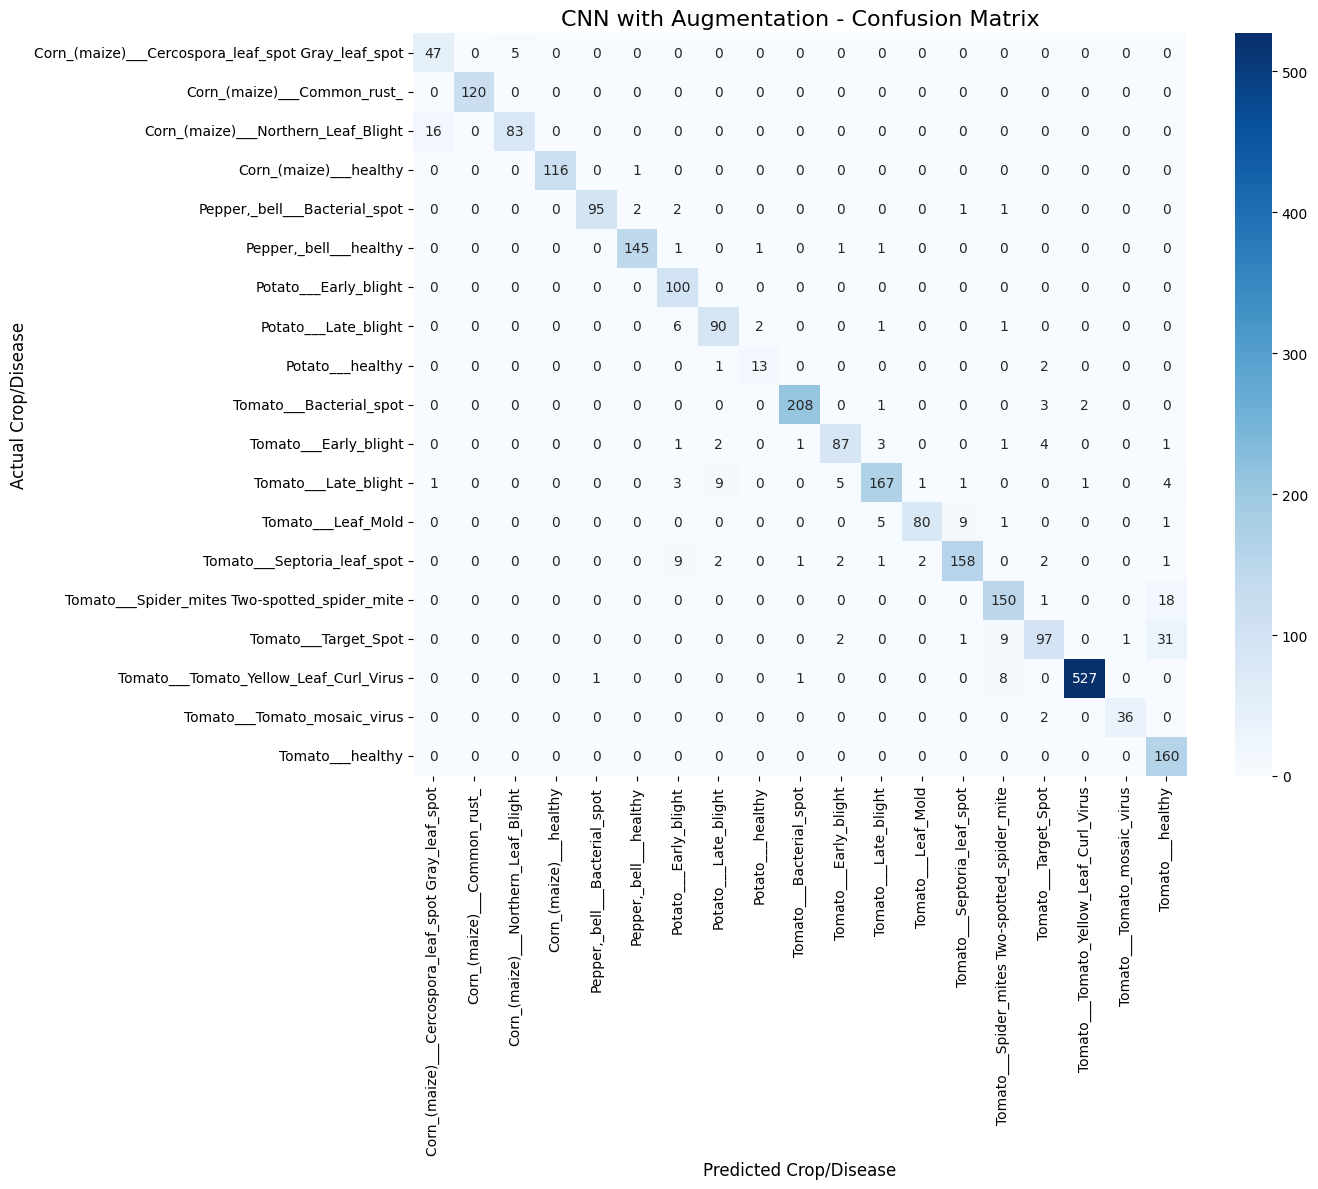

In [12]:
# Evaluate the trained model on the unseen test set: accuracy, per-class metrics, confusion matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Overall accuracy on the test set
print("Evaluating model on unseen test data...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nOverall Test Accuracy: {test_acc * 100:.2f}%\n")

# 2. Predictions for the confusion matrix and metrics
test_generator.reset()
print("Generating predictions...")
predictions = model.predict(test_generator)

# Convert softmax probability vectors into single predicted class indices
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# 3. Precision, Recall, F1-Score per class
class_labels = list(test_generator.class_indices.keys())
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

# 4. Confusion Matrix -- shows which classes get mixed up with which
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('CNN with Augmentation - Confusion Matrix', fontsize=16)
plt.ylabel('Actual Crop/Disease', fontsize=12)
plt.xlabel('Predicted Crop/Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 6. Demo Samples
Automatically pulls one labeled image per class from the test set into `demo_samples/`,
named as `ClassName__originalfilename.jpg` so the true label is visible from the filename.
This replaces manually copying files one at a time.

**What this does:** Automatically builds a small demo folder (`demo_samples/`) by picking one random image from each class in the test set and copying it over, renamed as `ClassName__originalfilename.jpg` so the true label is visible directly from the filename. This saves us from manually hunting through test folders when we want a quick set of labeled example images for a demo or presentation. The commented-out lines at the end are an optional way to zip the folder and download it locally.

In [13]:
# Build a small folder of one sample image per class, for quick demoing/presentation
import os
import random
import shutil

test_dir = 'data_split/test'
sample_dir = 'demo_samples'
os.makedirs(sample_dir, exist_ok=True)

# For every class folder in the test set, grab one random image and copy it,
# prefixing the filename with the true class name so the label is always visible
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        if images:
            chosen = random.choice(images)
            src = os.path.join(class_path, chosen)
            dst = os.path.join(sample_dir, f"{class_name}__{chosen}")
            shutil.copy(src, dst)

print(f"Copied {len([f for f in os.listdir(sample_dir) if not f.startswith('.')])} sample images into '{sample_dir}/'")

# Zip for download (optional — uncomment to use)
# shutil.make_archive('demo_samples', 'zip', sample_dir)
# from google.colab import files
# files.download('demo_samples.zip')


Copied 19 sample images into 'demo_samples/'


**What this does:** Defines a helper function `demo_from_test_set()` that picks a completely random image from a random class in the test set, runs it through the trained model, and displays the image alongside its **true label**, the model's **predicted label**, and the model's **confidence** (the highest softmax probability, as a percentage). This is a quick, repeatable way to visually sanity-check individual predictions.

In [14]:
# Helper function: predict on a random test-set image and display the result
import random
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def demo_from_test_set(model, class_labels, test_dir='data_split/test', img_size=(128, 128)):
    # Pick a random class, then a random image from that class
    class_name = random.choice(os.listdir(test_dir))
    class_path = os.path.join(test_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and preprocess the image exactly like during training (resize + rescale to 0-1)
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # Run the model and extract the top predicted class + its confidence
    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Display the image with true label vs. predicted label for a quick visual check
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {class_name}\nPredicted: {predicted_class}\nConfidence: {confidence:.1f}%")
    plt.show()

    return class_name, predicted_class, confidence


**What this does:** Calls the helper defined above to run one random demo prediction and display it. Re-running this cell picks a new random image each time.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step


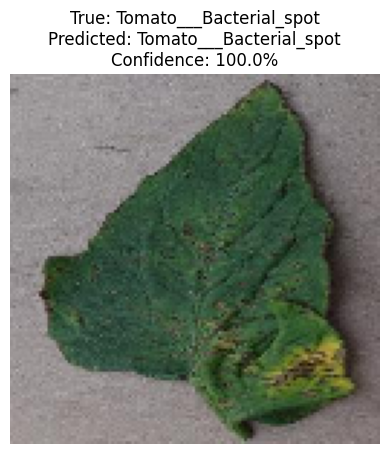

('Tomato___Bacterial_spot', 'Tomato___Bacterial_spot', np.float32(99.95071))

In [15]:
# Run one random demo prediction (re-run this cell to try a different random image)
demo_from_test_set(model, class_labels)


## 7. Live Demo
`quick_demo()` — upload one image, see the predicted class and confidence.
`launch_gradio_demo()` — interactive drag-and-drop widget with top-3 predictions (better for final presentation).

**Note on real-world images:** this model was trained on PlantVillage's studio-style photos
(uniform backgrounds, consistent lighting). It performs well on test images from that same
distribution, but confidence and accuracy can drop on photos taken in real field conditions
with different backgrounds/lighting — a known limitation worth discussing in the report.

**What this does:** Defines two live-demo options for testing the model on a brand-new image (not from the dataset):

- `quick_demo()` prompts you to upload a single image file directly in Colab, runs it through the model, and displays the predicted class with its confidence.
- `launch_gradio_demo()` installs and launches a [Gradio](https://gradio.app/) web widget with drag-and-drop image upload and a bar chart of the **top-3** predicted classes — a nicer, more interactive option for a live presentation, and shareable via a temporary public link (`share=True`).

In [16]:
# Two live-demo options: (A) simple upload-and-predict, (B) interactive Gradio widget
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


def quick_demo(model, class_labels, img_size=(128, 128)):
    """
    Option A: Quick Colab file-upload demo.
    Prompts you to upload an image, then shows the predicted class and confidence.
    """
    from google.colab import files

    # Prompt the user to upload one leaf image
    print("Upload a leaf image to test...")
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Preprocess the uploaded image the same way as training data (resize + rescale)
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict and pull out the top class + confidence
    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Show the uploaded image with its prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.1f}%")
    plt.show()

    return predicted_class, confidence


def launch_gradio_demo(model, class_labels, img_size=(128, 128)):
    """
    Option B: Interactive Gradio widget with drag-and-drop upload and
    top-3 predictions shown as a confidence bar chart.
    """
    # Install Gradio on the fly since it isn't part of the base Colab environment
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    import gradio as gr

    # Prediction function that Gradio will call every time a user submits an image
    def predict_disease(img):
        img_resized = img.resize(img_size)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        prediction = model.predict(img_array)[0]
        # Return a dict of {class_name: probability} -- Gradio's Label output renders this as a bar chart
        return {class_labels[i]: float(prediction[i]) for i in range(len(class_labels))}

    # Build and launch the interactive web interface (share=True gives a temporary public link)
    demo = gr.Interface(
        fn=predict_disease,
        inputs=gr.Image(type="pil"),
        outputs=gr.Label(num_top_classes=3),
        title="Crop Disease Detector",
        description="Upload a leaf photo to detect disease (Group 9 - AI Project)"
    )
    demo.launch(share=True)
    return demo


**What this does:** Runs **Option A** — triggers the simple upload-and-predict demo defined above. Uploading a leaf photo here will show the model's prediction and confidence.

Upload a leaf image to test...


Saving corn_di1.jpeg to corn_di1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


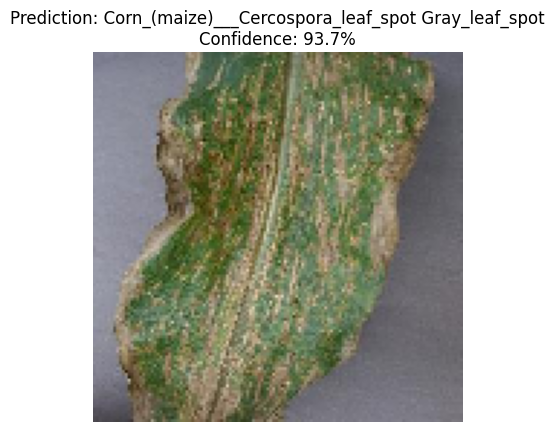

('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', np.float32(93.70043))

In [17]:
# Run Option A - quick upload demo (uploads a single image, shows one prediction)
quick_demo(model, class_labels)


**What this does:** Runs **Option B** — launches the interactive Gradio web widget defined above, giving a drag-and-drop interface and a live top-3 confidence chart. This is the better option for a final live presentation/demo.

In [18]:
# Run Option B - interactive Gradio widget (drag-and-drop upload, top-3 predictions chart)
launch_gradio_demo(model, class_labels)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4439aa6084807cd086.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio Interface for: predict_disease
-------------------------------------
inputs:
|-<gradio.components.image.Image object at 0x7e2b4c10fdd0>
outputs:
|-<gradio.components.label.Label object at 0x7e2b4c058200>